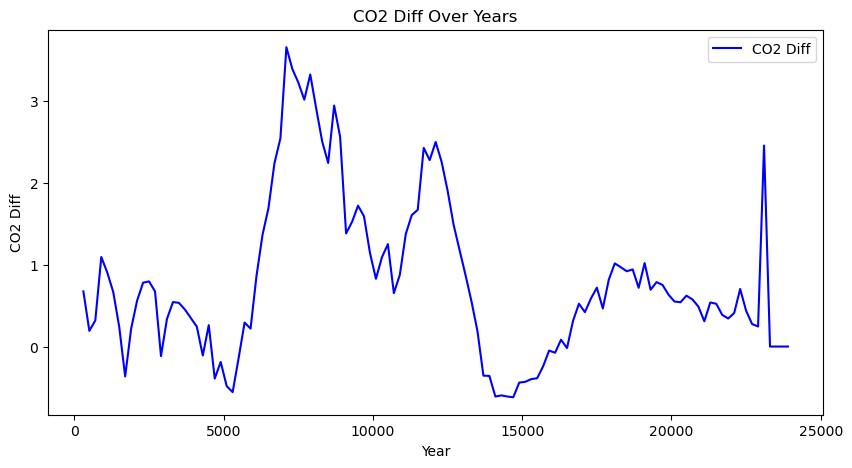

In [58]:

import xarray as xr
import pandas as pd
import numpy as np


ds_sat_diff = xr.open_dataset('LGMR_data/ds_sat_diff.nc')
ds_sat_ens_diff= xr.open_dataset('LGMR_data/ds_sat_ens_diff.nc')
ds_sat_ens= xr.open_dataset('LGMR_data/ds_sat_ens_flipped.nc')

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")
df_obl = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\obl.csv")

df_co2_diff = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\co2_diff.csv")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# plot df_co2_diff
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_co2_diff['age'], df_co2_diff['co2_diff'], label='CO2 Diff', color='blue')
plt.xlabel('Year')
plt.ylabel('CO2 Diff')
plt.title('CO2 Diff Over Years')
plt.legend()


In [43]:
df_co2_diff

,age,co2_diff
0,300,0.672344
1,500,0.191235
2,700,0.319924
3,900,1.092859
4,1100,0.902924
...,...,...
114,23100,NaN
115,23300,NaN
116,23500,NaN
117,23700,NaN


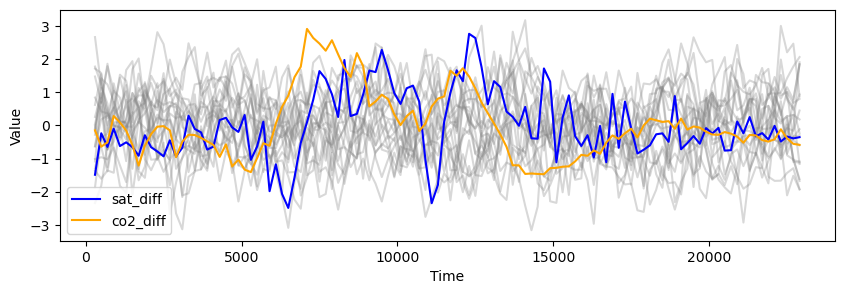

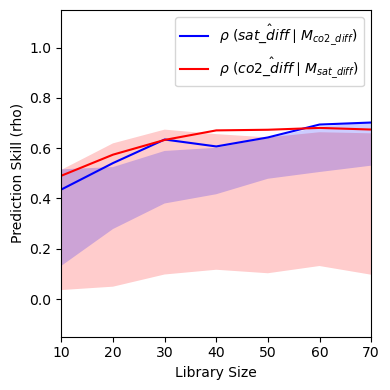

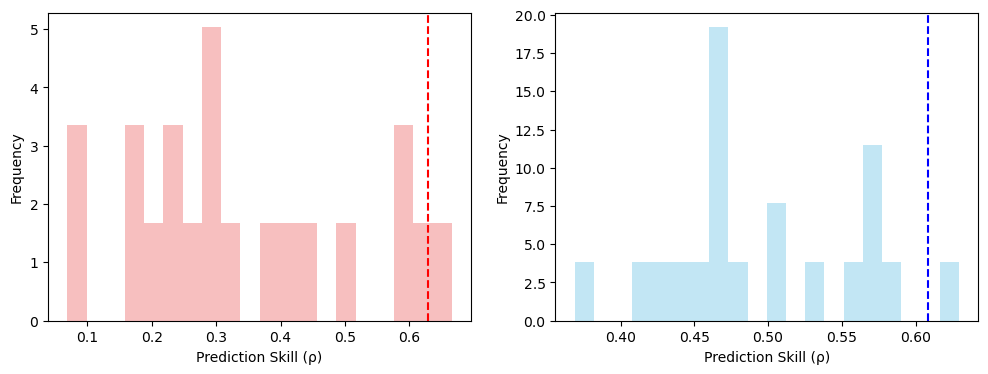

(True, True)


In [47]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

ccm_out, ran_ccm_list_xy, test_result=st.ccm_significance_test_v3(ds_sat_diff, df_co2_diff, lat_idx=80, lon_idx=0,
    E=5, 
    tau=-4, 
    n_ran=20, 
    libSizes="10 20 30 40 50 60 70",
    Tp=-10,
    sample=10,
    random =True,
    flip_pre= False,
    showPlot=True
)

print(test_result)

In [55]:
from toolbox import Tp_ana as ta
import importlib
importlib.reload(ta)
 
df_AT_diff = ds_sat_diff.isel(lat=80, lon=0).to_dataframe().reset_index()
# only keep the columns 'age' and 'sat_diff'
df_AT_diff = df_AT_diff[['age', 'sat_diff']]
df_AT_diff

# df_AT_diff = df_AT_diff.rename(columns={'age': 'age', 'sat_diff': 'sat_diff'})
Tps_list, forward_rhos, reverse_rhos = ta.find_optimal_Tp(
    df_sd      = df_AT_diff,
    df_pre     = df_co2_diff,
    E          = 4,
    tau        = -2,
    libSizes   = "100",
    sample     = 100,
    Tps        = range(-10, 11),
    interactive=True   
)

CCM v3:   0%|          | 0/13824 [00:00<?, ?it/s]

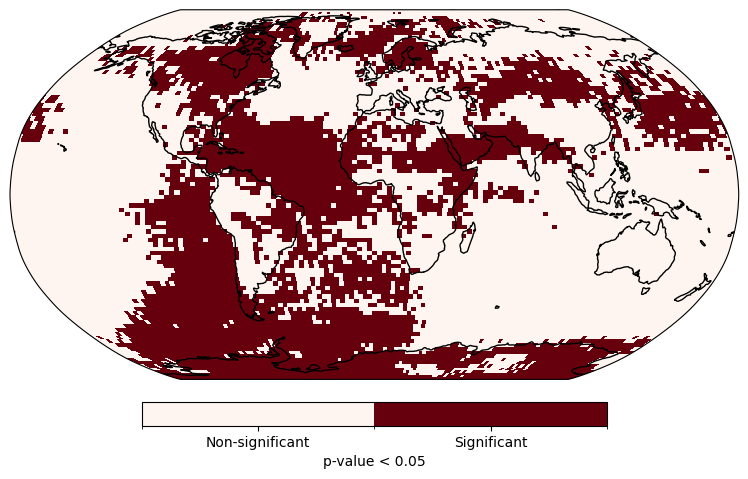

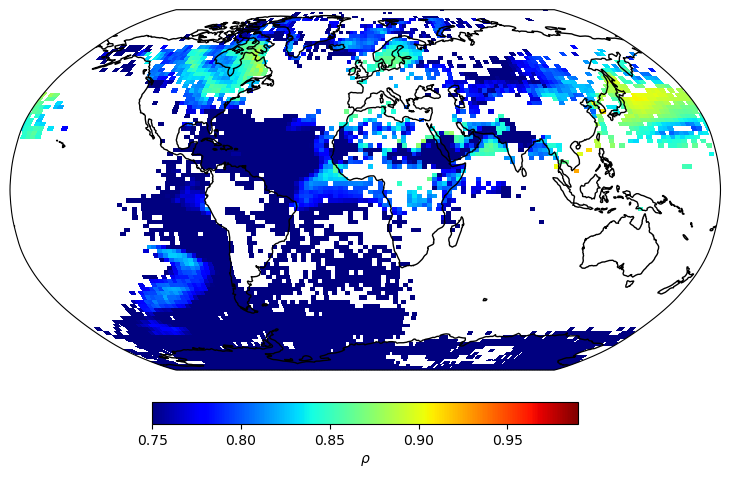

In [56]:
from toolbox import significant_map  as sm
import importlib
importlib.reload(sm)




CO2_sig_map_Tpm8,CO2_rho_map_Tpm8=sm.sig_map_rho_allinone(ds_sat_diff, df_pre,
                                   E=5, tau=-4, Tp=-8, libSizes="10 20 30 40 50 60 70 80",
                                   n_ran=100, sample=10, random=True, function='v3', mode='bi', show_figure=True)

import pickle
with open("output/CO2_sig_map_Tpm8.pkl", "wb") as f:
    pickle.dump(CO2_sig_map_Tpm8, f)

with open("output/CO2_rho_map_Tpm8.pkl", "wb") as f:
    pickle.dump(CO2_rho_map_Tpm8, f)


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

processed_rho_map_Tpm8_CO2=cm.postprocess_rho_map(CO2_rho_map_Tpm8, CO2_sig_map_Tpm8)
cm.plot_rho_map(processed_rho_map_Tpm8_CO2, ds_sat_diff, v_range=[0.75, 0.99], color_map='jet')

# save processed_rho_map_Tp0_uncertainty_ana
with open("output/processed_rho_map_Tpm8_CO2.pkl", "wb") as f:
    pickle.dump(processed_rho_map_Tpm8_CO2, f)


In [59]:
from toolbox import significant_map  as sm
import importlib
importlib.reload(sm)




CO2_sig_map_Tp0,CO2_rho_map_Tp0=sm.sig_map_rho_allinone(ds_sat_diff, df_pre,
                                   E=5, tau=-4, Tp=0, libSizes="10 20 30 40 50 60 70 80",
                                   n_ran=100, sample=10, random=True, function='v3', mode='bi', show_figure=True)

import pickle
with open("output/CO2_sig_map_Tp0.pkl", "wb") as f:
    pickle.dump(CO2_sig_map_Tp0, f)

with open("output/CO2_rho_map_Tp0.pkl", "wb") as f:
    pickle.dump(CO2_rho_map_Tp0, f)


from toolbox import ccm_map as cm
import importlib
importlib.reload(cm)

processed_rho_map_Tp0_CO2=cm.postprocess_rho_map(CO2_rho_map_Tp0, CO2_sig_map_Tp0)
cm.plot_rho_map(processed_rho_map_Tp0_CO2, ds_sat_diff, v_range=[0.75, 0.99], color_map='jet')

# save processed_rho_map_Tp0_uncertainty_ana
with open("output/processed_rho_map_Tp0_CO2.pkl", "wb") as f:
    pickle.dump(processed_rho_map_Tp0_CO2, f)

CCM v3:   0%|          | 0/13824 [00:00<?, ?it/s]

KeyboardInterrupt: 